<a href="https://colab.research.google.com/github/lallen-student/hw-test/blob/main/DACSS_603_Tutorial_7_Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading and inspecting data

This tutorial will introduce simple linear regression. Simple linear regression is regression with only one explanatory variable and it is the "simple" version of multiple linear regression.

We will work with the UN98 and Davis datasets from the 'carData' package (uploaded to GitHub for convenience). Let's load the data and remove the variables we will not be working with.

In [ ]:
library(dplyr)
library(ggplot2)
 # load the UN98 data, which contains United Nations data from around 1998
UN98 <- readRDS(url('https://github.com/omerfyalcin/colab-data/blob/main/UN98.rds?raw=true'))
Davis <- readRDS(url('https://github.com/omerfyalcin/colab-data/blob/main/Davis.rds?raw=true'))
UN98 <- UN98 %>%
  select(c(infantMortality, GDPperCapita, illiteracyMale, illiteracyFemale)) # select the four variables to use


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




As always, we should get to know the data.
Let's use the `head()` function to inspect the first few rows of the data.frame:

In [ ]:
head(UN98)

,infantMortality,GDPperCapita,illiteracyMale,illiteracyFemale
,<int>,<int>,<dbl>,<dbl>
Afghanistan,154,2848,52.800,85.00
Albania,32,863,NA,NA
Algeria,44,1531,26.100,51.00
American.Samoa,11,NA,0.264,0.36
Andorra,NA,NA,NA,NA
Angola,124,355,NA,NA



The dataset now contains the following variables:

- **infantMortality**: infant deaths per 1000 live births.

- **GDPperCapita**: gross domestic product per person in U.S. dollars.

- **illiteracyMale**:percentage of males 15 years of age and older who are illiterate

- **illiteracyFemale**:percentage of females 15 years of age and older who are illiterate

- Just by using the head() function, we are able to see that there are some missing values, denoted by `NA`. Yet, this method will not always work in detecting missing values since head() prints only a certain number of top rows. (Also, visually inspecting the entire dataset would be exhausting.)

- Instead, we can use the is.na() function to show which elements are missing.
Let's use head again to only display top six rows.

In [ ]:
is.na(UN98) %>% head()

,infantMortality,GDPperCapita,illiteracyMale,illiteracyFemale
Afghanistan,FALSE,FALSE,FALSE,FALSE
Albania,FALSE,FALSE,TRUE,TRUE
Algeria,FALSE,FALSE,FALSE,FALSE
American.Samoa,FALSE,TRUE,FALSE,FALSE
Andorra,TRUE,TRUE,TRUE,TRUE
Angola,FALSE,FALSE,TRUE,TRUE


Another way to look into the data is using the `str()` function, which summarizes the structure of an R object.

In [ ]:
str(UN98)

'data.frame':	207 obs. of  4 variables:
 $ infantMortality : int  154 32 44 11 NA 124 24 22 25 6 ...
 $ GDPperCapita    : int  2848 863 1531 NA NA 355 6966 8055 354 20046 ...
 $ illiteracyMale  : num  52.8 NA 26.1 0.264 NA NA NA 3.8 0.3 NA ...
 $ illiteracyFemale: num  85 NA 51 0.36 NA NA NA 3.8 0.5 NA ...


The results shows us that this is a data.frame object that has 4 variables (columns) and 207 observations (rows). It also tells us that two of the variables are integer vectors while the other two are numeric (and none are, say, factor or logical).

Let's get some numerical summary of the data with the `summary()` function.

In [ ]:
summary(UN98)

 infantMortality   GDPperCapita   illiteracyMale   illiteracyFemale
 Min.   :  2.00   Min.   :   36   Min.   : 0.200   Min.   : 0.200  
 1st Qu.: 12.00   1st Qu.:  442   1st Qu.: 2.952   1st Qu.: 4.847  
 Median : 30.00   Median : 1779   Median :10.829   Median :20.100  
 Mean   : 43.48   Mean   : 6262   Mean   :17.555   Mean   :27.906  
 3rd Qu.: 66.00   3rd Qu.: 7272   3rd Qu.:27.575   3rd Qu.:48.025  
 Max.   :169.00   Max.   :42416   Max.   :79.100   Max.   :93.400  
 NA's   :6        NA's   :10      NA's   :47       NA's   :47      

The summary() function can provide a good first check to seeing if everything looks fine with the data. For example, if we had seen a maximum value greater than 1000 in the *infantMortality* variable, we would have caught an error before going any further, since it is measured 'per 1000 live births.'

The summary also shows the number of missing variables (NA's) for each variable.

We can also compare two variables directly looking at summary. For example, we can see that the median and mean male illiteracy rate are lower than the mean and median female illiteracy rate.

## Explarotary Visualization

A simple linear regression model represents the relationship between two variables with a straight line.
Scatterplots are a good visual tool to check if it makes sense to model the relationship between two variables in this way.

The `pairs()` function produces a matrix of scatterplots.

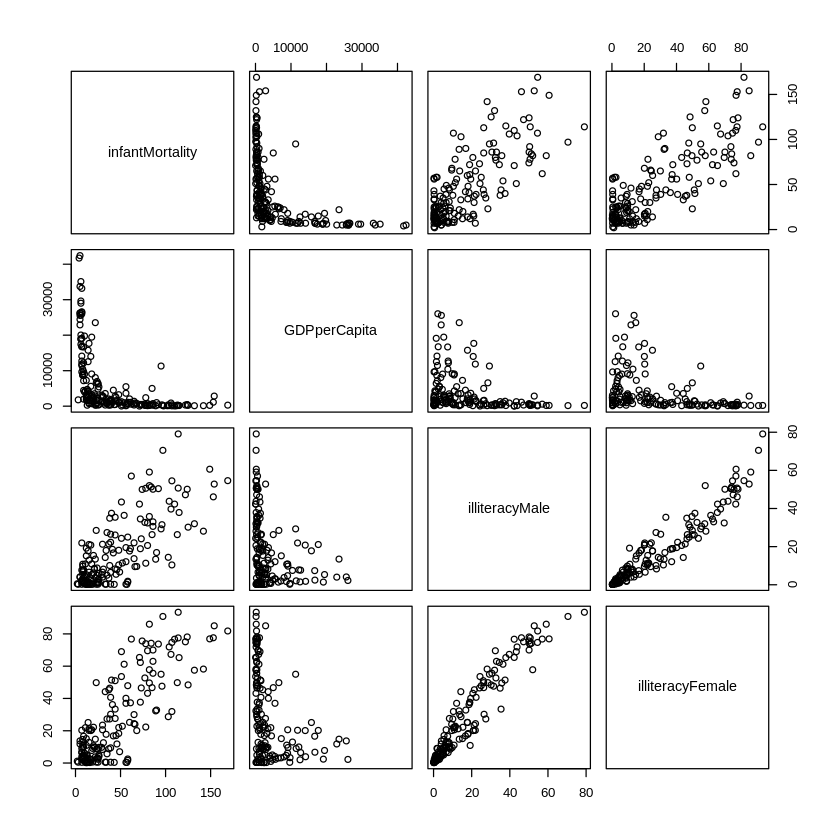

In [ ]:
pairs(UN98)

Notice that the lower and upper panels are symmetric and show the same information.

The relationship between some pairs of variables are represented better with a straight line than others.
For example, it seems like countries with high female illiteracy rates also have high male illiteracy rate.
Similarly, both of the illiteracy rates seem to also be positively related to infant mortality rates.

The relationship of GDP per capita to other variables is a bit different in that all scatterplots that include it look somewhat curvy.

This points to diminishing returns from increasing GDP per capita: all of the other outcomes seem to initially change fast with increasing GDP per capita, but they then slow down.

Let's inspect the scatterplot of GDPperCapita and infantMortality:

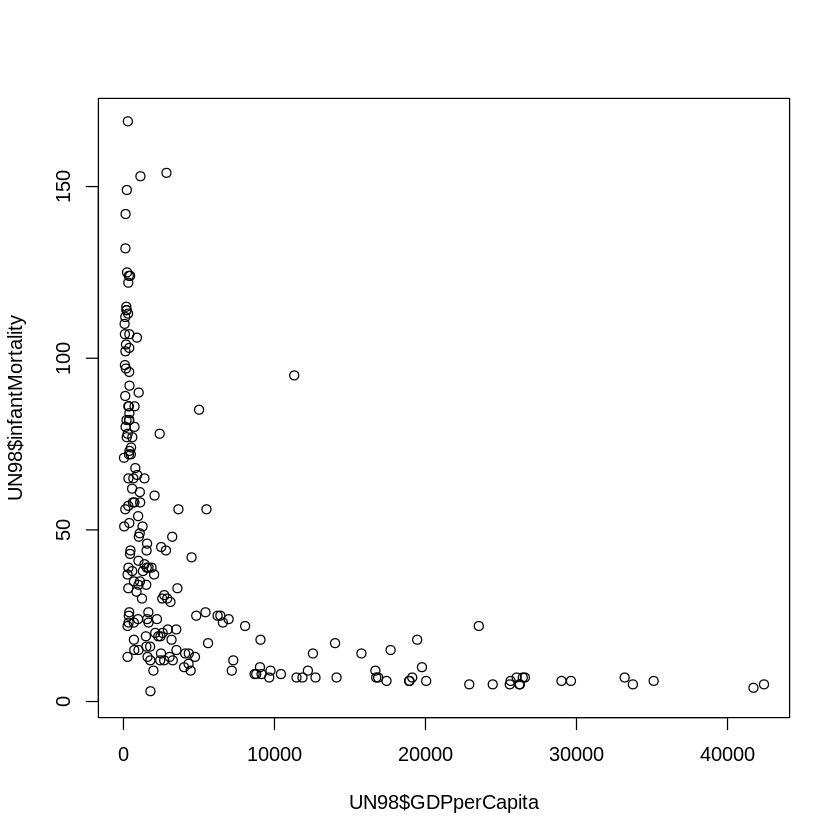

In [ ]:
plot(x = UN98$GDPperCapita, y = UN98$infantMortality)

Notice how going from 0 to 10000 GDP per capita corresponds to a dramatic reduction in infant mortality, but infant mortality changes very little going from 10000 to 40000 in GDP per capita.

Now, create a scatterplot with male illiteracy on the x-axis and female illiteracy on the y-axis.

In [ ]:
# Write your code here

Which of the two scatterplots is more appropriately represented by a straight line?

Now, re-create the scatterplot of GDPperCapita vs infantMortality, but wrap the GDPperCapita variable with `log()`, which will use the natural logarithm of the variable. Does the relationship now look more like a straight line?

In [ ]:
# Write your code here

We will cover the details of log transformations in future weeks, but this small example shows how they might be useful.

## Simple Linear Regression

The `lm()` function is used to fit a linear model in R.
Let's fit a model in which GDPperCapita is the explanatory variable (predictor) ($x$) and infantMortality as the response variable ($y$).

While we have already seen a positive trend visually, we don't have a good numerical understanding of the relationship.
For example, if we are presented two countries, one with 10% more of its population living in urban areas than others, what do we expect the difference between female life expectancy between these two countries in light of this data?
That's what the linear model will tell us.

The `lm()` function expects at least one mandatory argument: a formula which describes the model. In this case, we need to tell what our response (outcome) and explanatory variables (predictor) are, with the response variable being on the left hand-side.

In [ ]:
fit <- lm(infantMortality ~ GDPperCapita, data = UN98)

The `data` argument tells the function which data.frame the variables are part of. We could also directly use vectors, as in `lm(UN98$infantMortality~ UN98$GDPperCapita)`, but supplying data separately makes the formula more succinct.

The `summary()` function can be used on the model object to get a summary of the fitted model.
(As you remember, we had used `summary()` on the data.frame itself to get a summary of the data.frame. Now we're using it on the model object. `summary()` is a generic function that can be used with many object types and it will adapt its output style based on the object type.)

In [ ]:
summary(fit)


Call:
lm(formula = infantMortality ~ GDPperCapita, data = UN98)

Residuals:
   Min     1Q Median     3Q    Max 
-49.97 -26.40  -8.09  18.19 112.72 

Coefficients:
               Estimate Std. Error t value Pr(>|t|)    
(Intercept)  56.9238670  2.8743320  19.804  < 2e-16 ***
GDPperCapita -0.0022107  0.0002692  -8.213 3.18e-14 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 33.23 on 191 degrees of freedom
  (14 observations deleted due to missingness)
Multiple R-squared:  0.261,	Adjusted R-squared:  0.2571 
F-statistic: 67.45 on 1 and 191 DF,  p-value: 3.185e-14


Remember, the linear model has the form $E(y) = \alpha x + \beta$ and the least squares method (i.e. what lm() does) gives us an estimated line, $\hat \alpha$, called the slope, and $\hat \beta$, called the intercept.
The `lm()` function automatically includes an intercept in calculation, so we do not need to specify that.
The output shows the coefficient estimates: 56.92 for the intercept and -0.0022 for the slope, i.e. for the coefficient of the GDPperCapita variable.

The slope coefficient tells us that every 1 USD increase in GDP per capita corresponds to a decrease (because of the negative sign) in infant mortality of 0.0022 per a thousand infants.

Such small numbers are difficult to work with. It might make more sense to measure GDP per capita in thousands of dollars. Let's create a new variable that does that.

In [ ]:
UN98 %>%
  mutate(GDPperCapita2 = GDPperCapita / 1000) -> UN98
head(UN98)

,infantMortality,GDPperCapita,illiteracyMale,illiteracyFemale,GDPperCapita2
,<int>,<int>,<dbl>,<dbl>,<dbl>
Afghanistan,154,2848,52.800,85.00,2.848
Albania,32,863,NA,NA,0.863
Algeria,44,1531,26.100,51.00,1.531
American.Samoa,11,NA,0.264,0.36,NA
Andorra,NA,NA,NA,NA,NA
Angola,124,355,NA,NA,0.355


Now, fit a new model with the `lm()` function that uses the new GDPperCapita2 variable as the explanatory variable.
Then, use the `summary()` function to see the summary of the new model.

In [ ]:
# Write your code here

What changed in the model?

Now, the coefficient for the GDPperCapita2 variable represents the expected change in infantMortality that corresponds to a 1000 USD change in GDPperCapita. Everything else is the same. Other than making the output nicer (we deal with -2.2 as opposed to -0.0022), the model uses the exact same information and gives out the same information as the previous model.

The linear regression model minimizes the residual sum of squares. Residuals are the difference between actual values of the outcome variable ($y$) and the predicted values ($\hat y$).
The sum of squared residuals is $\sum (y - \hat y)^2$

Returning to our original `fit` object, we can see that residuals are one of the components of the object.


In [ ]:
names(fit)

[1] "coefficients"  "residuals"     "effects"       "rank"         
 [5] "fitted.values" "assign"        "qr"            "df.residual"  
 [9] "na.action"     "xlevels"       "call"          "terms"        
[13] "model"

We can reach the residuals directly. Let's see some of the values:

In [ ]:
head(fit$residuals)

Afghanistan     Albania     Algeria      Angola     Antigua   Argentina 
 103.372185  -23.016039   -9.539297   67.860929  -17.524184  -17.116740

Positive residuals point to underpredictions: the predicted value is less than the actual value.
Negative residuals point to overpredictions: the predicted value is more than the actual value.
The output above shows that the model overpredicts the mortality rate for Albania, Algeria, Antigua, and Argentina, and it underpredicts for Afghanistan and Angola.

We can take a look at the `fitted.values`, i.e. the model's predictions and contrast them to actual values.

In [ ]:
data.frame(actual = fit$model$infantMortality,
           prediction = fit$fitted.values,
           residual = fit$model$infantMortality - fit$fitted.values) %>% head()

,actual,prediction,residual
,<int>,<dbl>,<dbl>
Afghanistan,154,50.62782,103.372185
Albania,32,55.01604,-23.016039
Algeria,44,53.53930,-9.539297
Angola,124,56.13907,67.860929
Antigua,24,41.52418,-17.524184
Argentina,22,39.11674,-17.116740


We can use the `predict()` function to extrapolate our findings to other observations.
For example, what does our model expect the infant mortality rate to be for a hypothetical country that has a GDP per capita of 12350:

In [ ]:
predict(fit, data.frame(GDPperCapita = 12350))

1 
29.62182

We saw in the model that richer countries are expected to have fewer infant mortalities. Then a hypothetical country with 5000 USD GDP per capita must be predicted to have a higher rate than the example above. Use the `predict()` function to see if that is true.

In [ ]:
# Write your code here


## Interpretation

Let's take a look again to the output from the summary function.

Here's a breakdown of the output:

**Call:** A brief header is printed first, repeating the command that created the regression model.

**Residuals:** There is a section on residuals, showing summary information.

**Coefficients:** This part of the output provides basic information about the estimated regression coefficients.

- The first column lists the names of the regressors (explanatory variables) fit by `lm()`. The intercept is indicated with (Intercept).

- The column labeled ***Estimate*** provides the least-squares estimates of the regression coefficients.

- The column marked ***Std. Error*** displays the standard errors of the estimated coefficients. Standard errors are the standard deviation of a sampling distribution: it answers the question "if we repeatedly took samples and estimated the coefficients, what would be the standard deviation of the coefficient estimate?"

- The column marked ***t value*** is the ratio of each estimate to its standard error and is a test statistic for the null hypothesis that the corresponding population regression coefficient is equal to zero. If assumptions hold and the errors are normally distributed or the sample size is large enough, then these t-statistics computed with the default standard error estimates are distributed under the null hypothesis as t random variables with degrees of freedom (df) equal to the residual degrees of freedom under the model.

- The column marked ***Pr(>|t|)*** is the two-sided p-value for the null hypothesis assuming that the t-distribution is appropriate. In this specific case, the p-values are both very small, providing strong evidence against the null hypothesis that the population values for the intercept or the slope are equal to zero in favor of the alternative that they are non-zero.

- At the end of the coefficients column, there are stars. Those indicate "statistical significance", and the legend right below the coefficients show the meaning of the number of stars. In this case, the three stars mean the p-value is between 0 and 0.01. In other words, hypothesis tests were automatically conducted and their results are summarized in the stars. The tests use the conventional significance levels of 0.01, 0.05, 0.1, and report the lowest level at which the null hypothesis can be rejected.

Below the coefficient table is additional summary information, including the residual standard error of 33.23. This is the standard deviation of the residuals, but its calculated through a division by $n-2$ rather than $n-1$. Below it we see that 14 observations were deleted due to missingness. Our original dataframe had 207 rows, but we have 193 observations remaining after 14 are removed. The degrees of freedom is 191 $(n-2)$ in this case because we have two regressors, the intercept and the slope. We could calculate the residual standard error by:

In [ ]:
(sum((fit$residuals - mean(fit$residuals))^2) / 191) %>% sqrt()

[1] 33.23042

For some more great insight into residuals, please check this great blog post: [https://rpubs.com/iabrady/residual-analysis](https://rpubs.com/iabrady/residual-analysis)

- **The Multiple R-squared**, $R^2 ≈ 0.26$, is the square of the correlation between the response and the fitted values and is interpretable as the proportion of variation of the response variable around its mean accounted for by the regression.

Let's see that this is true:

In [ ]:
cor.test(UN98$infantMortality, UN98$GDPperCapita)


	Pearson's product-moment correlation

data:  UN98$infantMortality and UN98$GDPperCapita
t = -8.2128, df = 191, p-value = 3.185e-14
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.6082170 -0.3983659
sample estimates:
       cor 
-0.5108623 


The correlation between the two variables is -0.5108623, whose square is 0.2609083, equal to the r-squared.

Another way of thinking about r-squared is to divide the explained sum of squares to the total sum of squares (check lecture slides or SMSS for where this comes from):

In [ ]:
rss <-sum(fit$residuals^2) # residual sum of squares
tss <- var(UN98$infantMortality, na.rm = T) * 192
tss <- sum((fit$model$infantMortality - mean(fit$model$infantMortality, na.rm = T))^2, na.rm = T)
(tss - rss) / tss

[1] 0.2609803

Recall that, when doing scatterplots, the logged values of GDP per capita seemed to produce scatterplots that are more straight-line-like, indicating better fit. If so, logged values of GDP per capita must to a better job explaining the variation in infant mortality, which is exactly what r-squared looks at: the proportion of the variance in the response variable that is explained by the explanatory variable.

Fit a new model, this time using the `log(GDPperCapita)` as the explanatory variable and print out the summary. Has the r-squared changed?

In [ ]:
# Write your code here


While the F-statistic and the AIC/BIC values are less important at this point, here's a summary of what they do:

- The reported F-statistic provides a test of the general null hypothesis that all the population regression coefficients, except for the intercept, are equal to zero, versus the alternative that at least one of the explanatory variables is nonzero. If the errors are normal or n is large enough, then this test statistic has an F-distribution with the degrees of freedom shown. You can read more here: [https://statisticsbyjim.com/regression/interpret-f-test-overall-significance-regression/](https://statisticsbyjim.com/regression/interpret-f-test-overall-significance-regression/)

- The AIC and BIC values at the bottom of the output are, respectively, the Akaike Information Criterion and the Bayesian Information Criterion, statistics that are sometimes used for model selection. In general, lower values of AIC and BIC are better.


## Visualize the models

Let's visualize the first model:

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 14 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`geom_point()`).”


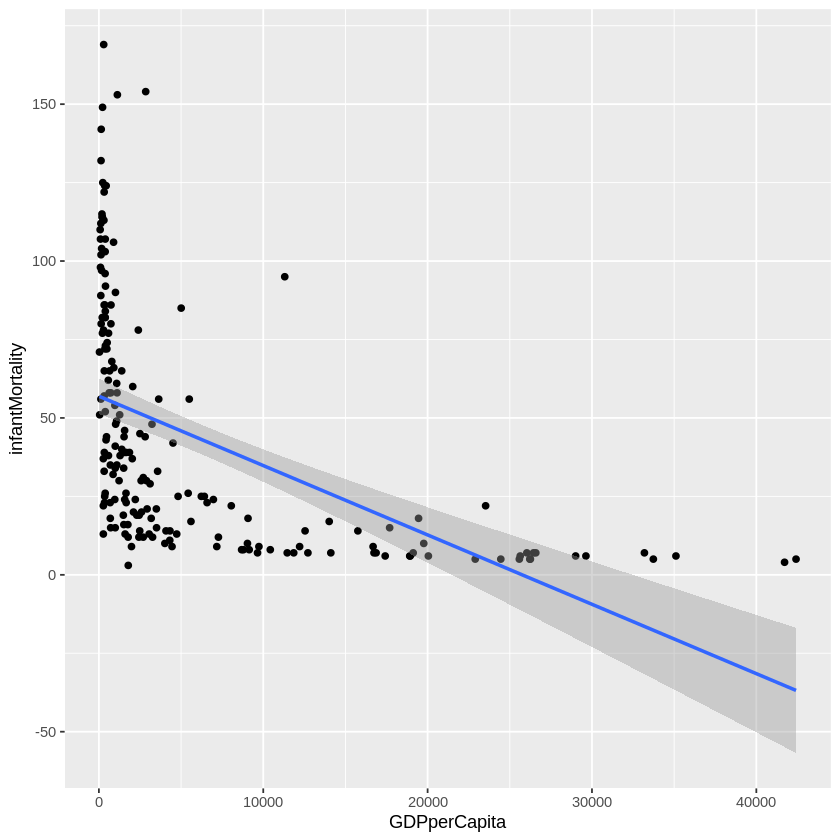

In [ ]:
ggplot(data = UN98, aes(x = GDPperCapita, y = infantMortality)) +
  geom_point() +
  geom_smooth(method = 'lm')

Now, use the same code, but wrap GDPperCapita with log, i.e. `log(GDPperCapita)`

In [ ]:
# Write your code here


The point should be obvious.

## Further Example

Let's do one more example of a simple linear regression:

The 'Davis' data set from the carData package contains the measured and self reported heights and weights of 200 men and women engaged in regular exercise. A few of the data values are missing, and consequently there are only 183 complete cases for the variables that are used in the analysis reported below. Let's see how our data looks like.

Use summary() and/or any other function you like to explore the Davis data set.

In [ ]:
# Write your code here


The variables in the dataset are

- **weight:** measured weight (in kilograms)
- **repwt:** reported weight (in kilograms)
- **height:** measured height (in centimeters)
- **repht:** reported height (in centimeters)

We are interested in determining whether the self-reports of height and weight are sufficiently accurate to replace the actual measurements.
In order to do this, we can regress each measurement on the corresponding self-report.
You may note that this prediction problem reverses the natural causal direction of the regression: regress the reports on the measurements.
While we can still fit this model, we will not be able to say that that the reported height is the cause of the actual height.
Fit a simple linear regression model in which the explanatory variable is reported weight and the outcome variable is weight.
Store the model object into a variable called `davis.mod`

In [ ]:
# Write your code here


Do you think reported weight does a good job at predicting the actual weight?

If individuals were unbiased reporters of their weight, then the regression intercept should be near zero and the slope near 1, E(y|x) = x. To assess this expectation, we can examine confidence intervals for the estimates using the standard R confint() function.

**NOTE: Copy the code for creating 'davis.mod' and paste it before all the code below. Uncomment all the code below.**

In [ ]:
# Write your code here



#confint(davis.mod)



The values intercept = 0 and slope = 1 are therefore marginally consistent with unbiased prediction of weight because these values are included in their respective confidence intervals, although the interval for the intercept is so wide that the coefficient estimates are unlikely to be of much value. (The separate confidence intervals do not address the hypothesis that simultaneously intercept = 0 and slope = 1 versus the alternative that either or both of the intercept and slope differ from these values, but we won't get into that here.)

We can obtain the scatterplot of measured weight (weight) by reported weight (repwt) for Davis’s data. The solid line is the least-squares linear regression line, and the broken line is the line of unbiased reporting y = x. (Don't worry about understanding the code.)

In [ ]:
# Write your code here




#plot(weight ~ repwt, data=Davis)
#abline(0, 1, lty="dashed", lwd=2)
#abline(davis.mod, lwd=2)
#legend("bottomright", c ("Unbiased Reporting", "Least Squares"), lty=c("dashed", "solid"), lwd=2, inset=0.02, cex = 0.3)

You may have noticed that there is one observation that is way above the regression line with a very high residuals (i.e. distance to curve). Since it's obviously the point with the highest residual, we can find which observation it is in a very "low tech" way (we'll see more systematic ways of doing this in the Assumptions & Diagnostics week).

In [ ]:
# Write your code here


#which(residuals(davis.mod) == max(residuals(davis.mod)))

Suppose we update our regression by refitting our model by omitting observation 12 and then recompute the confidence intervals:


In [ ]:
# Write your code here


#davis.mod.2 <- update(davis.mod, subset = -12)
#summary(davis.mod.2)
#confint(davis.mod.2)


Both the intercept and the slope change, but not dramatically, when the outlier is removed. This may be because the value of repwt for point 12 is near the center of the distribution of the regressor.

You may also note that there is a major change in the residual standard deviation, reduced from an unacceptable 8.4 kg to a possibly acceptable 2.2 kg. As a consequence, the coefficient standard errors are also much smaller when the outlier is removed, and the value of $R^2$ is greatly increased. Because the coefficient standard errors are now smaller, even though the estimated intercept is still close to zero and the estimated slope is close to 1, intercept = 0 and slope = 1 are both outside of the recomputed 95% confidence intervals for the coefficients. The positive intercept shows that people's actual weights are typically a little bit more than their reported weights.